In [1]:
!pip install --upgrade keras==2.15.0
!pip install --upgrade tensorflow==2.15.0.post1
!pip install --upgrade scipy==1.11.4
!pip install tensorflow-addons==0.21.0

# clone Impala repository, refresh folder to see the Imapala repository
# runtime -> change runtime -> choose a gpu/tpu
!git clone https://github.com/hubtru/Impala

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 11.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.17.0 requires keras>=3.2.0, but you have keras 2.15.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Succ

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_addons as tfa
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras as k
from keras import layers
from sklearn.model_selection import train_test_split
import cv2
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"

/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.11.0 and strictly below 2.14.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [3]:
# ============================== gpu info ==============================
print("Num GPUs Available: ", len(tf.config.list_physical_devices("GPU")))
print("GPUs: ", tf.config.list_physical_devices("GPU"))

Num GPUs Available:  0
GPUs:  []


In [4]:
# ============================== variables ==============================
# architecture
image_size = 256
filters = 256
depth = 4
columns = 4
widths = 4
kernel_size = 5
patch_size = 16
num_classes = 3

in_channel = 9
img_rows, img_cols = image_size, image_size
input_shape = (img_rows, img_cols, in_channel)

learning_rate = 0.001
weight_decay = 0.0001
batch_size = 8
epochs = 20

# varibale for tokenizer
NUM_PATCHES = 16

In [5]:
# ============================== paths ==============================
# needed for generate_data
modality = "scal"
exp_name = f"impala3d_v3_token"
sub_exp_name = "base"
model_name = f"{exp_name}_{modality}_{sub_exp_name}"
model_save_path = f"{model_name}.h5"

# dataset
csv_path = "/content/Impala/dataset/labels_sample.csv"
scal_path = f"/content/Impala/dataset/{modality}"

In [6]:
# ============================== load/prepare dataset ==============================
df = pd.read_csv(csv_path)

# RANDOM DATASET: we switch to toolbased
# shuffle, need same state for tool/scal/chips/multi
np.random.seed(55)
df = df.iloc[np.random.permutation(len(df))]
# train/test/val : 70/15/15
train_df, test_df = train_test_split(df, test_size=0.3)
test_df, val_df = train_test_split(test_df, test_size=0.5)

print(
    "size check train/test/val",
    len(train_df),
    len(test_df),
    len(val_df),
    (len(train_df) + len(test_df) + len(val_df)),
)

train_df["scal_x"] = train_df.id.map(lambda id: f"{scal_path}/x/{id}.png")
test_df["scal_x"] = test_df.id.map(lambda id: f"{scal_path}/x/{id}.png")
val_df["scal_x"] = val_df.id.map(lambda id: f"{scal_path}/x/{id}.png")

train_df["scal_y"] = train_df.id.map(lambda id: f"{scal_path}/y/{id}.png")
test_df["scal_y"] = test_df.id.map(lambda id: f"{scal_path}/y/{id}.png")
val_df["scal_y"] = val_df.id.map(lambda id: f"{scal_path}/y/{id}.png")

train_df["scal_z"] = train_df.id.map(lambda id: f"{scal_path}/z/{id}.png")
test_df["scal_z"] = test_df.id.map(lambda id: f"{scal_path}/z/{id}.png")
val_df["scal_z"] = val_df.id.map(lambda id: f"{scal_path}/z/{id}.png")


size check train/test/val 14 3 3 20


<Figure size 600x600 with 0 Axes>

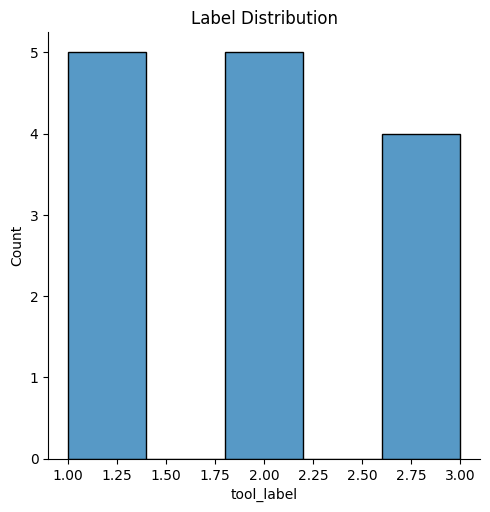

In [7]:
plt.figure(figsize=(6,6))
sns.displot(train_df['tool_label'])
plt.title('Label Distribution')
plt.show()

In [8]:
print("check if permutation is same on all models")
print("train_head", train_df.head())
print("test_head", test_df.head())
print("val_head", val_df.head())

check if permutation is same on all models
train_head          id image_label  tool_label  \
14   T8R3B4       sharp           1   
10   T6R9B3        used           2   
0    T1R2B1       sharp           1   
3   T2R13B4      dulled           3   
1    T1R7B4        used           2   

                                        scal_x  \
14   /content/Impala/dataset/scal/x/T8R3B4.png   
10   /content/Impala/dataset/scal/x/T6R9B3.png   
0    /content/Impala/dataset/scal/x/T1R2B1.png   
3   /content/Impala/dataset/scal/x/T2R13B4.png   
1    /content/Impala/dataset/scal/x/T1R7B4.png   

                                        scal_y  \
14   /content/Impala/dataset/scal/y/T8R3B4.png   
10   /content/Impala/dataset/scal/y/T6R9B3.png   
0    /content/Impala/dataset/scal/y/T1R2B1.png   
3   /content/Impala/dataset/scal/y/T2R13B4.png   
1    /content/Impala/dataset/scal/y/T1R7B4.png   

                                        scal_z  
14   /content/Impala/dataset/scal/z/T8R3B4.png  
10   /conte

In [9]:
def read_specs(file_paths_x, file_paths_y, file_paths_z, img_rows, img_cols, channels):
    """
    Reads the spectogram files from disk and normalizes the pixel values
      @params:
        file_paths - Array of file paths to read from
        img_rows - The image height.
        img_cols - The image width.
        as_grey - Read the image as Greyscale or RGB.
        channels - Number of channels.
      @returns:
        The created and compiled model (Model)
    """
    images = []
    for i in range(file_paths_x.size):
        img = []
        img_x = cv2.imread(file_paths_x[i])
        res_x = cv2.resize(
            img_x, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )
        img.append(res_x)

        img_y = cv2.imread(file_paths_y[i])
        res_y = cv2.resize(
            img_y, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )
        img.append(res_y)

        img_z = cv2.imread(file_paths_z[i])
        res_z = cv2.resize(
            img_z, dsize=(img_rows, img_cols), interpolation=cv2.INTER_CUBIC
        )

        img.append(res_z)
        img = np.concatenate(img, axis=2)
        images.append(img)

    images = np.asarray(images, dtype=np.float32)

    # normalize
    images = images / np.max(images)

    return images

In [10]:
x_train_scal = read_specs(
    train_df.scal_x.values,
    train_df.scal_y.values,
    train_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)
x_test_scal = read_specs(
    test_df.scal_x.values,
    test_df.scal_y.values,
    test_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)
x_val_scal = read_specs(
    val_df.scal_x.values,
    val_df.scal_y.values,
    val_df.scal_z.values,
    img_rows,
    img_cols,
    in_channel,
)

In [11]:
x_train_scal.shape

(14, 256, 256, 9)

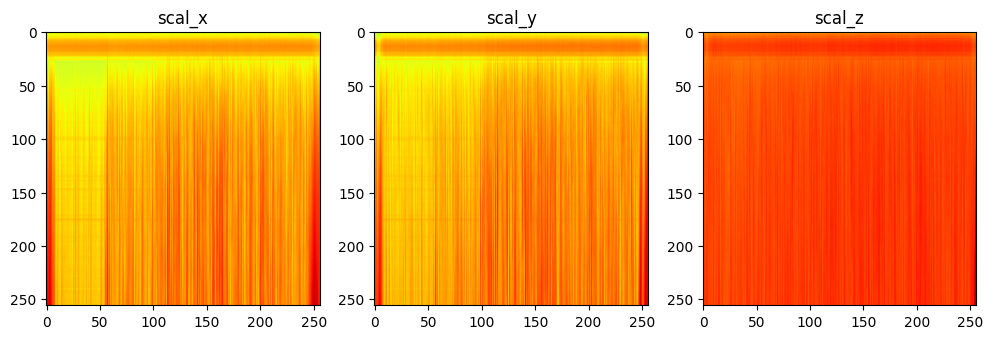

In [12]:
pil_img_x = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,:3],axis=-1))
pil_img_y = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,3:6],axis=-1))
pil_img_z = tf.keras.utils.array_to_img(np.flip(x_train_scal[0][:,:,6:9],axis=-1))

fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(pil_img_x)
ax[1].imshow(pil_img_y)
ax[2].imshow(pil_img_z)
ax[0].set_title("scal_x")
ax[1].set_title("scal_y")
ax[2].set_title("scal_z")
plt.show()

In [ ]:
labels_train = train_df.tool_label.values
labels_test = test_df.tool_label.values
labels_val = val_df.tool_label.values

labels_train

array([1, 2, 1, 3, 2, 2, 3, 2, 1, 1, 3, 1, 2, 3])

In [ ]:
labels_train = labels_train - 1
labels_test = labels_test - 1
labels_val = labels_val - 1

labels_train = tf.keras.utils.to_categorical(
    labels_train, num_classes=num_classes, dtype="float32"
)
labels_test = tf.keras.utils.to_categorical(
    labels_test, num_classes=num_classes, dtype="float32"
)
labels_val = tf.keras.utils.to_categorical(
    labels_val, num_classes=num_classes, dtype="float32"
)

In [ ]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_scal, labels_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_scal, labels_test))
val_dataset = tf.data.Dataset.from_tensor_slices((x_val_scal, labels_val))

In [ ]:
# ============================== augment ==============================
auto = tf.data.AUTOTUNE

data_augmentation = k.Sequential(
    [
        k.layers.RandomBrightness(factor=(-0.2, 0.2), value_range=(0, 1)),
        k.layers.RandomContrast(factor=0.2),
        k.layers.GaussianNoise(stddev=0.2),
    ],
    name="data_augmentation",
)

In [ ]:
def generate_datasets(images, is_train=False, shuffle=False):
    dataset = images
    if shuffle:
        dataset = dataset.shuffle(batch_size * 10)
    dataset = dataset.batch(batch_size)
    if is_train:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x), y), num_parallel_calls=auto
        )
    return dataset.prefetch(auto)

In [ ]:
train_ds = generate_datasets(train_dataset, is_train=True, shuffle=True)
val_ds = generate_datasets(val_dataset)
test_ds = generate_datasets(test_dataset)

In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 9), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

In [ ]:
# https://keras.io/examples/vision/token_learner/
def patch_attention(inputs, number_of_paches=NUM_PATCHES):
    # Layer normalize the inputs.
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)  # (B, H, W, C)

    # Applying Conv2D => Reshape => Permute
    # The reshape and permute is done to help with the next steps of
    # multiplication and Global Average Pooling.
    attention_maps = k.Sequential(
        [
            # 3 layers of conv with gelu activation as suggested
            # in the paper.
            layers.Conv2D(
                filters=number_of_paches,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_paches,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            layers.Conv2D(
                filters=number_of_paches,
                kernel_size=(3, 3),
                activation=tf.nn.gelu,
                padding="same",
                use_bias=False,
            ),
            # This conv layer will generate the attention maps
            layers.Conv2D(
                filters=number_of_paches,
                kernel_size=(3, 3),
                activation="sigmoid",  # Note sigmoid for [0, 1] output
                padding="same",
                use_bias=False,
            ),
            # Reshape and Permute
            layers.Reshape((-1, number_of_paches)),  # (B, H*W, num_of_paches)
            layers.Permute((2, 1)),
        ]
    )(
        x
    )  # (B, num_of_paches, H*W)

    # Reshape the input to align it with the output of the conv block.
    num_filters = inputs.shape[-1]
    inputs = layers.Reshape((1, -1, num_filters))(inputs)  # inputs == (B, 1, H*W, C)

    # Element-Wise multiplication of the attention maps and the inputs
    attended_inputs = (
        attention_maps[..., tf.newaxis] * inputs
    )  # (B, num_tokens, H*W, C)

    outputs = tf.reduce_mean(attended_inputs, axis=1)

    # Instead of GAP, reshape the tensor back to the original shape
    outputs = layers.Reshape((patch_size, patch_size, num_filters))(outputs)

    return outputs

In [ ]:
def activation_module(x):
    x = layers.Activation("gelu")(x)
    return layers.BatchNormalization()(x)


def base_module(x, filters: int, patch_size: int):
    x = layers.Conv2D(filters, kernel_size=patch_size, strides=patch_size)(x)
    return activation_module(x)


def depth_point_module(
    x, pe_block, column, level, depth, width, r_arr, filters: int, kernel_size: int
):
    if column == 0:
        # Depthwise convolution.
        x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x)
        x = layers.Add()([activation_module(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_module(x)

        if width != 0:
            x0 = fusion_block_double(r_arr[width - 1][column][level], x0)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)
        return x, r_arr
    elif column != 0:
        if level == 0:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], pe_block)
        elif level <= depth - 2:
            x0 = fusion_block_double(r_arr[width][column - 1][level + 1], x)
            if width != 0:
                x = fusion_block_double(r_arr[width - 1][column - 1][level + 1], x)
        else:
            x0 = x
        x = layers.DepthwiseConv2D(kernel_size=kernel_size, padding="same")(x0)
        x = layers.Add()([activation_module(x), x0])  # Residual.

        # Pointwise convolution.
        x = layers.Conv2D(filters, kernel_size=1)(x)
        x = activation_module(x)

        x = fusion_block_double(r_arr[width][column - 1][level], x)
        if width != 0:
            x = fusion_block_double(r_arr[width - 1][column][level], x)

        r_arr = reverasable_output_array(x, r_arr, width, column, level)

        return x, r_arr

    return x, r_arr


def fusion_block_double(x, y):
    return layers.Add()([x, y])


def reverasable_output_array(x, r_arr, width, column, level):
    r_arr[width][column][level] = x
    return r_arr


def load_depth_point(
    image_size=image_size,
    filters=filters,
    depth=depth,
    columns=columns,
    width=widths,
    kernel_size=kernel_size,
    patch_size=patch_size,
    num_classes=num_classes,
):
    r_arr = [
        [[None for _ in range(depth)] for _ in range(columns)] for _ in range(width)
    ]

    inputs = k.Input(input_shape)
    # x = layers.Rescaling(scale=1.0 / 255)(inputs)         # already rescaled

    # Extract patch embeddings.
    x = base_module(inputs, filters, patch_size)
    pe_block = x

    # ConvMixer blocks.
    for w in range(width):
        for column in range(columns):
            for level in range(depth):
                if (
                    level == (depth // 2)
                    and column == (columns // 2)
                    and w == (width // 2)
                ):
                    print("created tokenizer")
                    x = patch_attention(x)
                x, r_arr = depth_point_module(
                    x, pe_block, column, level, depth, w, r_arr, filters, kernel_size
                )

    # Classification block.
    x = layers.GlobalAvgPool2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return k.Model(inputs, outputs)

In [ ]:
def launch_experiment(model):
    optimizer = tfa.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
    )

    _, accuracy = model.evaluate(test_ds)
    print(f"Test accuracy: {round(accuracy * 100, 2)}%")

    return history, model

In [ ]:
model = load_depth_point()
model.summary()

created tokenizer
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 9  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 16, 16, 256)  590080      ['input_1[0][0]']                
                                                                                                  
 activation (Activation)        (None, 16, 16, 256)  0           ['conv2d[0][0]']                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 16, 16, 256)  1024       ['activatio

In [ ]:
history, model = launch_experiment(model)

Epoch 1/20
2/2 [==============================] - 79s 10s/step - loss: 11.5102 - accuracy: 0.5000 - val_loss: 218.5897 - val_accuracy: 0.3333
Epoch 2/20
2/2 [==============================] - 10s 5s/step - loss: 20.4733 - accuracy: 0.5000 - val_loss: 15.9913 - val_accuracy: 0.3333
Epoch 3/20
2/2 [==============================] - 8s 3s/step - loss: 15.4170 - accuracy: 0.5000 - val_loss: 349.2647 - val_accuracy: 0.6667
Epoch 4/20
2/2 [==============================] - 8s 4s/step - loss: 24.2355 - accuracy: 0.4286 - val_loss: 185.4977 - val_accuracy: 0.6667
Epoch 5/20
2/2 [==============================] - 10s 5s/step - loss: 8.8078 - accuracy: 0.6429 - val_loss: 91.3016 - val_accuracy: 0.6667
Epoch 6/20
2/2 [==============================] - 9s 4s/step - loss: 10.6634 - accuracy: 0.5714 - val_loss: 128.1531 - val_accuracy: 0.3333
Epoch 7/20
2/2 [==============================] - 8s 4s/step - loss: 7.3324 - accuracy: 0.6429 - val_loss: 13.0408 - val_accuracy: 0.6667
Epoch 8/20
2/2 [=====

In [ ]:
model.save(model_save_path)

In [ ]:
pred = model.predict(test_ds)

1/1 [==============================] - 8s 8s/step


In [ ]:
# ============================== generate data ==============================
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import interp
from itertools import cycle
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import PredictionErrorDisplay
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras as k

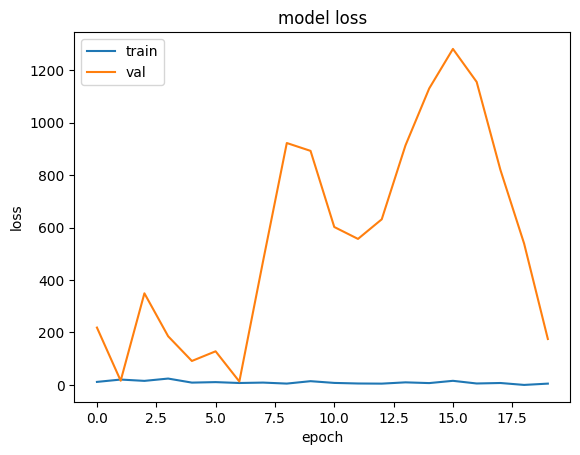

In [ ]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

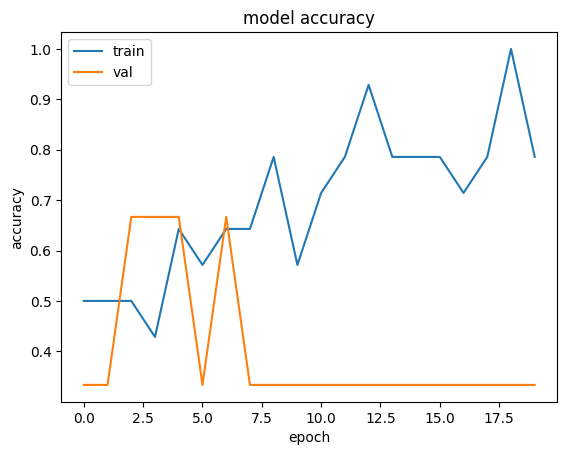

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

1/1 [==============================] - 0s 446ms/step


<ipython-input-30-0227eecc12f4>:27: DeprecationWarning: scipy.interp is deprecated and will be removed in SciPy 2.0.0, use numpy.interp instead
  mean_tpr += interp(all_fpr, fpr[i], tpr[i])


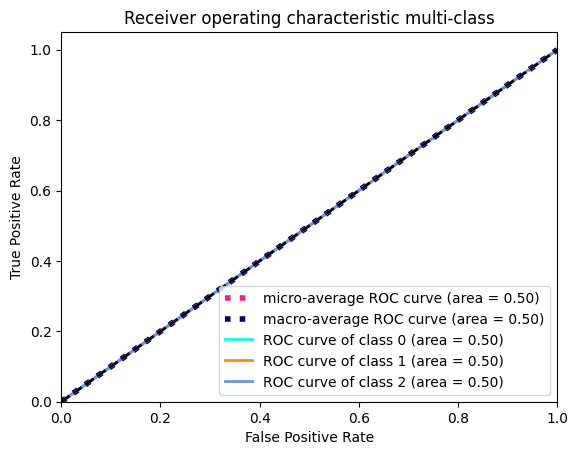

In [ ]:
x_test = test_ds
y_test = labels_test
y_score = model.predict(x_test)
y_test = y_test

n_classes = num_classes
# Plot linewidth.
lw = 2
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at this points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += interp(all_fpr, fpr[i], tpr[i])

# Finally average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure(1)
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label="micro-average ROC curve (area = {0:0.2f})" "".format(roc_auc["micro"]),
    color="deeppink",
    linestyle=":",
    linewidth=4,
)

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label="macro-average ROC curve (area = {0:0.2f})" "".format(roc_auc["macro"]),
    color="navy",
    linestyle=":",
    linewidth=4,
)

colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=lw,
        label="ROC curve of class {0} (area = {1:0.2f})" "".format(i, roc_auc[i]),
    )

plt.plot([0, 1], [0, 1], "k--", lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic multi-class")
plt.legend(loc="lower right")
plt.show()

In [ ]:
y_classes = np.argmax(y_score, axis=1)
labels_test_f1 = np.argmax(y_test, axis=1)

print(metrics.confusion_matrix(labels_test_f1, y_classes))
print(classification_report(labels_test_f1, y_classes))

[[0 1 0]
 [0 1 0]
 [0 1 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(labels_test_f1, y_classes, pos_label=2)
print("AUC: ", metrics.auc(fpr, tpr))

AUC:  0.5
